## 2. Final project draft

Create a draft version of your final project that contains all of the required components. See the [project assignment](https://github.com/mlmldata24/Final-Project-Assignment) for a detailed list of requirements.

Note that this draft will only be graded on the criteria listed under "reproducibility," not depth of analysis. However, this draft will be used to provide you with feedback, so the more you include the better feedback we can give.

This project draft will be turned in through a separate Github repository that you create (instructions will be provided in a Git tutorial in class).

# Introduction

Juvenile white sharks (JWS; Carcharodon carcharias) rely on shallow coastal nursery habitats that provide
favorable thermal conditions, reduced predation risks, and access to prey items curing early life stages (Anderson et al., 2022; Huepel et al., 2007; Dewar et al., 2004). Understanding how sharks, in these vulnerable life stages, move in a fine-scale acoustic array can help describe residency within their preferred habitat, horizontal space and depth use through time, in relation to temperature. In this draft, I will be using a VEMCO Positioing System (VPS) array dataset collected by past CSULB Shark Lab master's student Emily Spurgeon in 2021. It is a .rds file that will help me analyze temperature and JWS movement behavior within the array. As explained above, I will do my best to emphasize the importance on the reproducibility of this dataset that will aid in answering my broader thesis questions about residency, horizontal & vertical depth use, excluding temperature to save for the final draft.

In [1]:
#Not sure how long this should be for the first draft? Given we are emphasizing reproducibility of code

# Description of Methods and Data Source

The .rds file, prodived by Emily Spurgeon & the Shark Lab, are entered using the pyreadr package and converted into an applicable dataframe. After loading this file, I printed or read the file to see the format of the data and different columns. I then was helped by Emily Spurgeon on how how to clean the dataset to tailor for my specific project goals. Timestamps were converted to datetime, and temporal month/hour variables were simplified. Any columns with negative or inappropriate values, and NA values were filtered out because there was an error or in logging sensors.

First, the raw detection counts of only 2 individual JWS within the array were visualized to show positioning. If all individuals were used in the figure, data points would be to cluststered. I then created a bar chart to show the residency index (RI) values to show which indivduals may have spent the most time within the array. the RI equation was used from past acoustic telemetry tools to track fine-scale movement (Kraft et al., 2023). This was calculated as the proportion of days detected relative to the time between the first and last detection triangulated between three acoustic receivers in the array. Later,I created spatial visualizations using detected coordinates in the array to depict the Horizontal Position Error (HPE), which is the measurement of precision of the recorded location (Kraft et al., 2023). Lastly, I created a subset containing the DateTimePT and DepthData, then month and hour variables from the df2021 dataframe. Mean depth is calculated across each month and hour. This was done using "for" loops for each month and hour, and calculating the mean depth in numpy. NaN were assigned if there were no values present, then filtered out in analysis. I visualized the dataset using a basic line plot, with hour of the day placed on the x-axis and mean depth in meters placed on the y-axis, while separate lines represents each month of the year. With the totality of this code and data, they answer how JWS behave in nearshore environments vertically and horizontally. In the later draft, temperature will be analyzed to determine how temperature influences their movement within the array. Also, I may want to potentially use a temperature model called the Feed Forward Neural Network (FFNN) to asign temperatures values to JWS throughout their vertical and horizontal movement (Spurgeon et al., 2022).

# Results

In [2]:
import pyreadr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import periodogram
from scipy.signal.windows import hann
import xarray as xr
import cartopy.crs as ccrs
from scipy import stats

In [3]:
#Data cleaning

In [4]:
result = pyreadr.read_r("vps_data_subset.rds")
df = result[None]

In [5]:
print(df.shape)
print(df.columns)
df.head()

(186049, 21)
Index(['DateTimePT', 'DateTimeUTC', 'Transmitter', 'Tag_shortName', 'Latitude',
       'Longitude', 'HPE', 'TempData', 'DepthData', 'AccelData', 'Date',
       'Time', 'month', 'year', 'tag_family', 'when_encountered',
       'tag_location', 'capture_method', 'sex', 'TNL_cm',
       'est_tag_expiry_date'],
      dtype='object')


,DateTimePT,DateTimeUTC,Transmitter,Tag_shortName,Latitude,Longitude,HPE,TempData,DepthData,AccelData,...,Time,month,year,tag_family,when_encountered,tag_location,capture_method,sex,TNL_cm,est_tag_expiry_date
0,2021-06-01 04:00:29.353306112,2021-06-01 04:00:29.353306112,A69-1602-41962,2021-13,34.407004,-119.552286,4.908078,NaN,NaN,NaN,...,21:00:00,May,2021,V13-1x-BLU-3,4/1/2021,Del Mar,dart,M,152.0,3/9/2022
1,2021-06-01 04:02:23.118352896,2021-06-01 04:02:23.118352896,A69-9001-4339,2021-02,34.405452,-119.551313,6.119533,NaN,NaN,NaN,...,21:00:00,May,2021,V16-4x-069k-3,3/17/2021,Carpinteria,dart,F,183.0,3/16/2025
2,2021-06-01 04:03:52.210982912,2021-06-01 04:03:52.210982912,A69-1602-41962,2021-13,34.406659,-119.553018,5.873375,NaN,NaN,NaN,...,21:00:00,May,2021,V13-1x-BLU-3,4/1/2021,Del Mar,dart,M,152.0,3/9/2022
3,2021-06-01 04:06:01.224570112,2021-06-01 04:06:01.224570112,A69-1602-41962,2021-13,34.405990,-119.552941,4.518145,NaN,NaN,NaN,...,21:00:00,May,2021,V13-1x-BLU-3,4/1/2021,Del Mar,dart,M,152.0,3/9/2022
4,2021-06-01 04:07:08.218270976,2021-06-01 04:07:08.218270976,A69-9001-4324,2020-12,34.405461,-119.551035,4.715414,NaN,NaN,NaN,...,21:00:00,May,2021,V16-4x-069k-2,4/26/2020,Carpinteria,dart,F,230.0,4/25/2024


In [6]:
#Emily Spurgeon helped me with cleaning of data

In [7]:
df["DateTimePT"] = pd.to_datetime(df["DateTimePT"], errors="coerce")
df["DateTimeUTC"] = pd.to_datetime(df["DateTimeUTC"], errors="coerce")
df['year'] = df['DateTimePT'].dt.year
df['month'] = df['DateTimePT'].dt.month
df['day'] = df['DateTimePT'].dt.date
df['hour'] = df['DateTimePT'].dt.hour
df['year'] = df['DateTimeUTC'].dt.year
df['month'] = df['DateTimeUTC'].dt.month
df['day'] = df['DateTimeUTC'].dt.date
df['hour'] = df['DateTimeUTC'].dt.hour

In [8]:
df2021 = df[df['year'] == 2021]. copy()
print(df2021.shape)
print(df2021[['year', 'month']].drop_duplicates().sort_values(['year', 'month']).head())

(186049, 23)
        year  month
0       2021      6
38684   2021      7
74475   2021      8
117507  2021      9
150076  2021     10


In [9]:
df2021 = df2021.dropna(subset=['Longitude', 'Latitude'])
df2021 = df2021.dropna(subset=['DepthData'])

In [10]:
df2021 = df2021.dropna(subset=['DateTimePT'])
df2021['day'] = df2021['DateTimePT'].dt.floor('D')
tags = sorted(df2021['Tag_shortName'].dropna().unique())
print(df2021)
print(tags)

                          DateTimePT                   DateTimeUTC  \
759    2021-06-01 19:46:17.835783936 2021-06-01 19:46:17.835783936   
764    2021-06-01 19:53:59.718046976 2021-06-01 19:53:59.718046976   
783    2021-06-01 20:19:12.788564992 2021-06-01 20:19:12.788564992   
787    2021-06-01 20:24:53.726191104 2021-06-01 20:24:53.726191104   
791    2021-06-01 20:27:24.554435072 2021-06-01 20:27:24.554435072   
...                              ...                           ...   
186035 2021-11-01 03:42:34.273235968 2021-11-01 03:42:34.273235968   
186037 2021-11-01 03:43:05.782657024 2021-11-01 03:43:05.782657024   
186039 2021-11-01 03:45:28.815681024 2021-11-01 03:45:28.815681024   
186042 2021-11-01 03:48:21.804258048 2021-11-01 03:48:21.804258048   
186045 2021-11-01 03:50:37.830880000 2021-11-01 03:50:37.830880000   

           Transmitter Tag_shortName   Latitude   Longitude       HPE  \
759      A69-9002-3593       2021-18  34.398915 -119.548158  7.179434   
764      A69-

In [11]:
#removing depth data with negative values (Emily said depth sensors were broken)

In [12]:
df2021 = df2021[df2021['DepthData'] >=0].copy()
print(df2021['DepthData'])

759       1.8194
764       1.8194
783       1.8194
787       1.8194
791       0.9097
           ...  
186035    6.3679
186037    3.6388
186039    1.8194
186042    0.0000
186045    7.2776
Name: DepthData, Length: 40234, dtype: float64


In [13]:
#residency index w/ acoutic array equation from Kraft et al., 2023

In [14]:
def residency_index(days_detected, first_day, last_day):
    """
    Calculate residency index within the VPS array
    
    Parameters:
    days_detected - number of unique days the shark was detected in the array
    first_day - first detection date
    last_day - last detection date
    
    Returns:
    ri - Residency index based on days detected divided by days 
        between first and last detection
    """
    detection_interval = (last_day - first_day).days + 1
    ri = days_detected / detection_interval
    return ri

In [15]:
ri_list = []

for tag in tags:
    sub = df2021[df2021['Tag_shortName'] == tag].copy()
    sub = sub.sort_values('DateTimePT')
    if len(sub) > 0:
        days_detected = len(sub['day'].dropna().unique())
        first_day = sub['DateTimePT'].min()
        last_day = sub['DateTimePT'].max()
        ri = residency_index(days_detected, first_day, last_day)
        ri_list.append([tag, days_detected, first_day, last_day, ri])
ri_df = pd.DataFrame(
    ri_list,
    columns=['Tag_shortName', 'days_detected', 'first_day', 'last_day', 'RI'])
print(ri_df)
print(tag, len(sub))

   Tag_shortName  days_detected                     first_day  \
0        2021-15            132 2021-06-02 18:39:58.564217088   
1        2021-18             21 2021-06-01 19:46:17.835783936   
2        2021-19             21 2021-06-01 20:27:24.554435072   
3        2021-20              1 2021-06-01 20:52:46.671439872   
4        2021-22             76 2021-06-02 18:26:54.720537856   
5        2021-23             35 2021-06-02 19:40:53.085673216   
6        2021-26            145 2021-06-02 20:34:17.659534080   
7        2021-27            148 2021-06-02 21:31:22.958753024   
8        2021-28             22 2021-06-02 22:18:29.316118016   
9        2021-31             16 2021-07-23 20:24:37.418531840   
10       2021-35              7 2021-08-04 16:00:00.778053888   
11       2021-36             81 2021-08-13 05:14:42.528924928   
12       2021-37             80 2021-08-13 02:51:56.149709824   
13       2021-43              2 2021-08-27 20:39:24.703671040   
14       2021-44         

In [16]:
#Preliminary Visualization of raw horizontal space use & residency in array

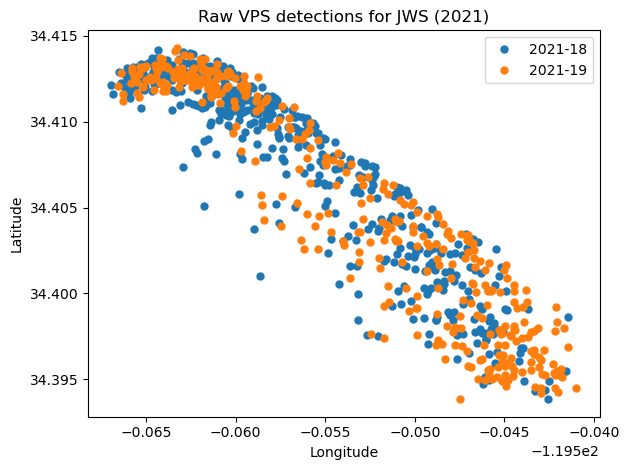

In [17]:
#only want to look at the first 2 individuals (gets clustered w/ all)
tags = df2021['Tag_shortName'].dropna().unique()

plt.figure()
for tag in tags[:2]:
    sub = df2021[df2021['Tag_shortName'] == tag]
    plt.plot(sub['Longitude'], sub['Latitude'], '.', ms=10, label=str(tag))
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Raw VPS detections for JWS (2021)')
plt.legend()
plt.tight_layout()
plt.show()

Figure 1: Displays the raw geo-positioning of two indivdual JWS within the Santa Barabar array.

In [18]:
#Secondary Visualization for RI within the array

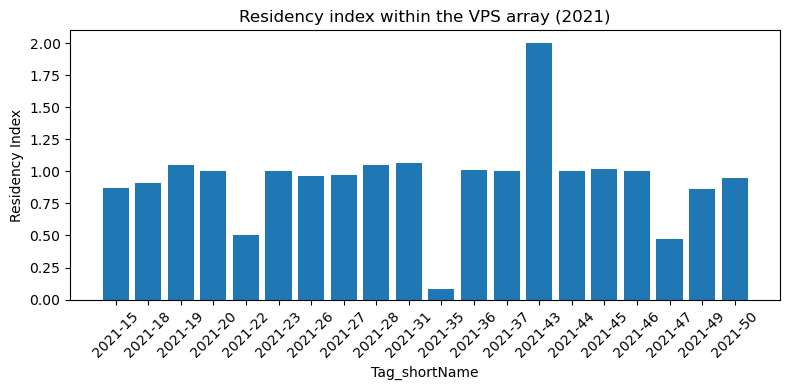

In [19]:
plt.figure(figsize=(8,4))
plt.bar(ri_df['Tag_shortName'].astype(str), ri_df['RI'])
plt.xlabel('Tag_shortName')
plt.ylabel('Residency Index')
plt.title('Residency index within the VPS array (2021)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Figure 2: Shows the RI values of each JWS that entered within the Santa Barabara array.

In [20]:
#Preliminary Visualization for HPE, too clustered

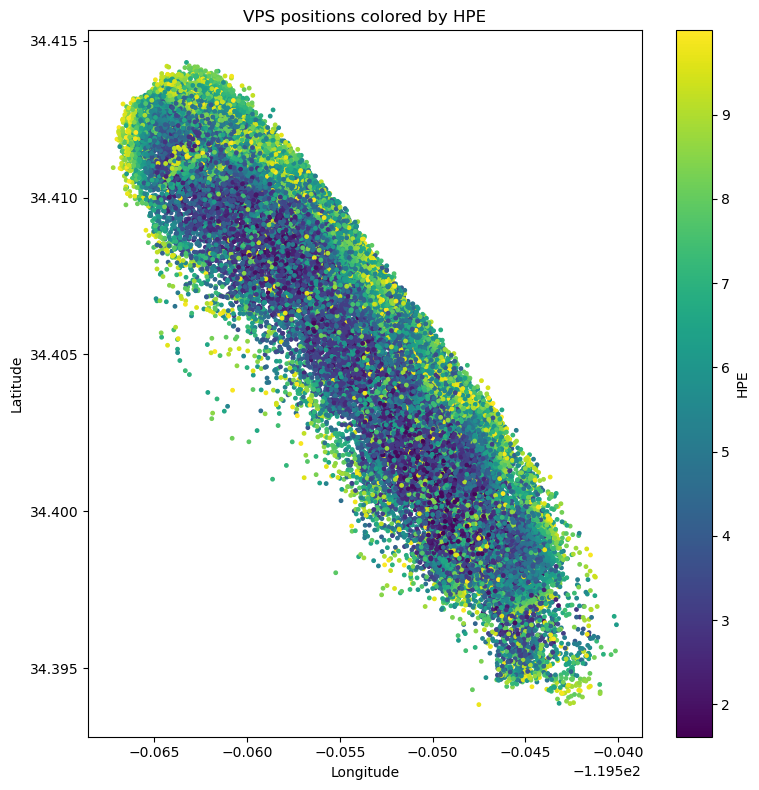

In [21]:
sub = df2021.dropna(subset=['Longitude', 'Latitude', 'HPE'])

plt.figure(figsize=(8,8))

plt.scatter(sub['Longitude'], sub['Latitude'], c=sub['HPE'], s=6)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('VPS positions colored by HPE')
plt.colorbar(label='HPE')
plt.tight_layout()
plt.show()

Figure 3: A scatterplot showing the HPE of all JWS individuals within the array. Color legend displays a gradient of high or low precision in tracking location.

In [22]:
#Secondary Visualization for HPE plot for first 2 individuals

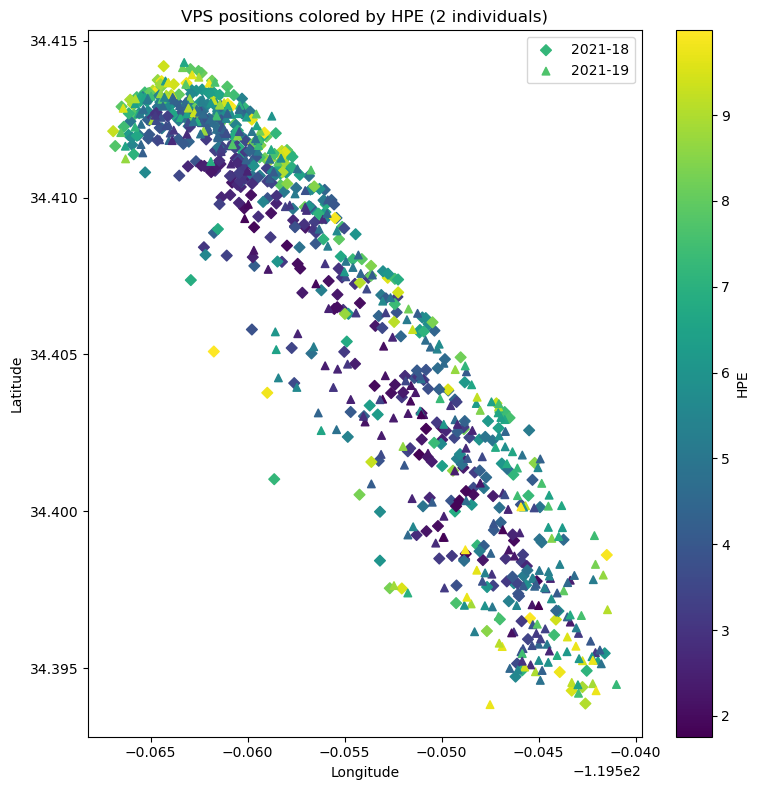

In [23]:
tags = df2021['Tag_shortName'].dropna().unique()

plt.figure(figsize=(8,8))
markers = ["D", "^"]
for i, tag in enumerate(tags[:2]):
    sub = df2021[
        (df2021['Tag_shortName'] == tag) &
        (df2021[['Longitude','Latitude','HPE']].notna().all(axis=1))]
    sc = plt.scatter(
    sub['Longitude'],
    sub['Latitude'],
    c=sub['HPE'],
    marker=markers[i],
    s=30,
    label=str(tag))
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('VPS positions colored by HPE (2 individuals)')
plt.colorbar(sc, label='HPE')
plt.legend()
plt.tight_layout()
plt.show()

Figure 3b: A display of HPE of 2 particular JWS within the Santa Barbara. Color legend displays a gradient of high or low precision in tracking location

In [24]:
#Depth distribution overtime

In [25]:
# Create hourly depth dataframe
depth_hourly = df2021[['DateTimePT', 'DepthData']].copy()
depth_hourly = depth_hourly.dropna(subset=['DepthData'])

# Make sure DateTimePT is datetime
depth_hourly['DateTimePT'] = pd.to_datetime(depth_hourly['DateTimePT'], errors='coerce')
depth_hourly = depth_hourly.dropna(subset=['DateTimePT'])

# Add month and hour columns
depth_hourly['month'] = depth_hourly['DateTimePT'].dt.month
depth_hourly['hour'] = depth_hourly['DateTimePT'].dt.hour

print(depth_hourly.head())
print(depth_hourly.shape)

                       DateTimePT  DepthData  month  hour
759 2021-06-01 19:46:17.835783936     1.8194      6    19
764 2021-06-01 19:53:59.718046976     1.8194      6    19
783 2021-06-01 20:19:12.788564992     1.8194      6    20
787 2021-06-01 20:24:53.726191104     1.8194      6    20
791 2021-06-01 20:27:24.554435072     0.9097      6    20
(40234, 4)


In [26]:
depth_overtime = df2021[['DateTimePT','DepthData']].copy()
depth_overtime = depth_hourly.dropna(subset=['DepthData'])
depth_overtime['month'] = depth_hourly['DateTimePT'].dt.month
depth_overtime['hour'] = depth_hourly['DateTimePT'].dt.hour
print(depth_overtime.head())

                       DateTimePT  DepthData  month  hour
759 2021-06-01 19:46:17.835783936     1.8194      6    19
764 2021-06-01 19:53:59.718046976     1.8194      6    19
783 2021-06-01 20:19:12.788564992     1.8194      6    20
787 2021-06-01 20:24:53.726191104     1.8194      6    20
791 2021-06-01 20:27:24.554435072     0.9097      6    20


In [27]:
month_list = np.sort(depth_overtime['month'].unique())
hour_list = np.arange(24)

depth_month_hour = []

for m in month_list:
    for h in hour_list:
        sub = depth_overtime[
            (depth_overtime['month'] == m) &
            (depth_overtime['hour'] == h)]
        if len(sub) > 0:
            mean_depth = np.mean(sub['DepthData'])
        else:
            mean_depth = np.nan
        depth_month_hour.append([m, h, mean_depth])
depth_month_hour = pd.DataFrame(depth_month_hour, columns=['month','hour','DepthData'])
print(depth_month_hour.head(10))

   month  hour  DepthData
0      6     0   1.863566
1      6     1   2.231164
2      6     2   2.712183
3      6     3   3.253269
4      6     4   2.080666
5      6     5   1.924926
6      6     6   1.828286
7      6     7   1.666831
8      6     8   1.769512
9      6     9   1.885608


In [28]:
#Visualization for mean depth use overtime

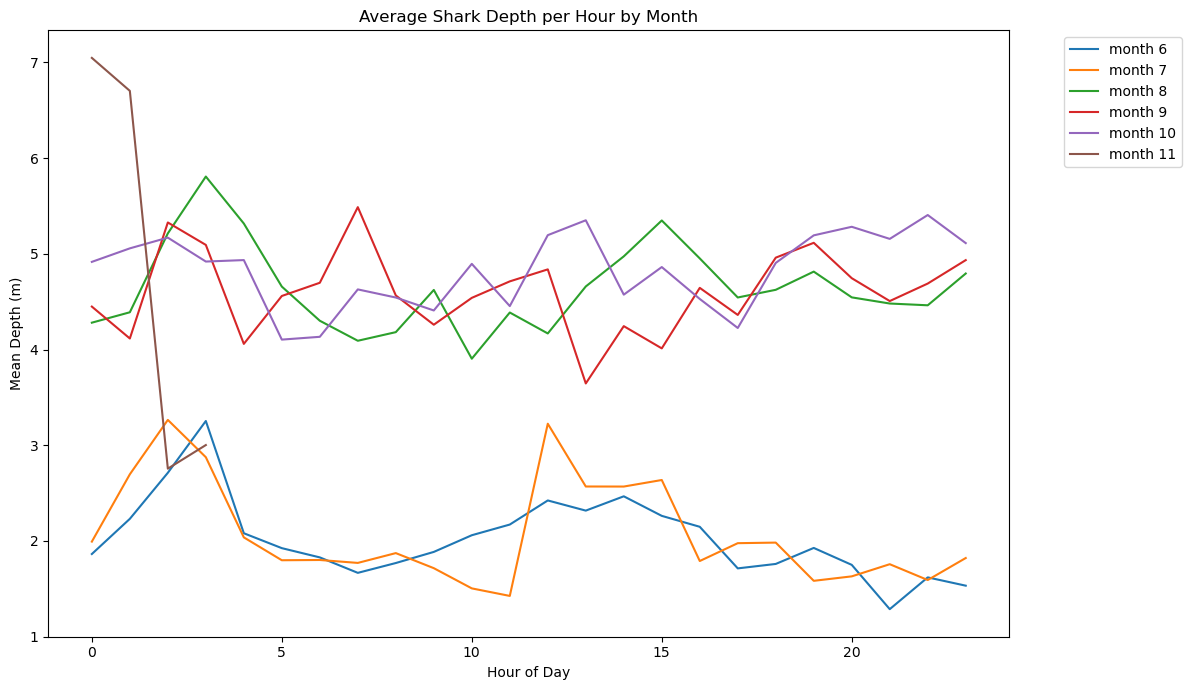

In [29]:
plt.figure(figsize=(12,7))

for m in month_list:
    sub = depth_month_hour[depth_month_hour['month'] == m]
    plt.plot(sub['hour'], sub['DepthData'], label='month ' + str(m))

plt.xlabel('Hour of Day')
plt.ylabel('Mean Depth (m)')
plt.title('Average Shark Depth per Hour by Month')
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

In [30]:
#Map of Research site!

In [31]:
import matplotlib.colors as colors

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import cartopy.crs as ccrs

In [33]:
from cartopy.io import shapereader

In [34]:
import cartopy.io.img_tiles as cimgt

In [35]:
!pip install folium

In [36]:
import folium

In [37]:
# Receiver longitude values
x = [
    -121.936425, -121.939108, -121.933306, -121.935631,
    -121.929967, -121.932613, -121.926748, -121.92362,
    -121.92609, -121.90658, -121.923332, -121.917698,
    -121.920565
]

# Receiver latitude values
y = [
    36.975787, 36.973743, 36.975281, 36.972876,
    36.974655, 36.972116, 36.973851, 36.973851,
    36.973851, 36.978851, 36.97279, 36.970553,
    36.97159
]

receiver_names = [f"R{i+1}" for i in range(len(x))]

In [38]:
# Receiver longitude values
x = [
    -121.936425, -121.939108, -121.933306, -121.935631,
    -121.929967, -121.932613, -121.926748, -121.92362,
    -121.92609, -121.90658, -121.923332, -121.917698,
    -121.920565
]

# Receiver latitude values
y = [
    36.975787, 36.973743, 36.975281, 36.972876,
    36.974655, 36.972116, 36.973851, 36.973851,
    36.973851, 36.978851, 36.97279, 36.970553,
    36.97159
]

receiver_names = [f"R{i+1}" for i in range(len(x))]

In [39]:
# Center map on the receiver array
center_lat = sum(y) / len(y)
center_lon = sum(x) / len(x)

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=15,
    tiles=None
)

# Add ESRI satellite imagery
folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/"
          "World_Imagery/MapServer/tile/{z}/{y}/{x}",
    attr="Esri World Imagery",
    name="Satellite",
    overlay=False,
    control=True
).add_to(m)

# Add receiver markers
for lon, lat, name in zip(x, y, receiver_names):
    folium.Marker(
        location=[lat, lon],
        popup=f"{name}<br>Lat: {lat}<br>Lon: {lon}",
        tooltip=name,
        icon=folium.Icon(color="red", icon="info-sign")
    ).add_to(m)

# Optional: connect receivers with a line
receiver_points = list(zip(y, x))
folium.PolyLine(
    receiver_points,
    color="yellow",
    weight=2,
    opacity=0.8
).add_to(m)

folium.LayerControl().add_to(m)

m

In [40]:
#Not the greatest. Try the new image without receiver sites

In [41]:
extent = [
    -121.96,  # west
    -121.87,  # east
    36.94,    # south
    37.01     # north
]

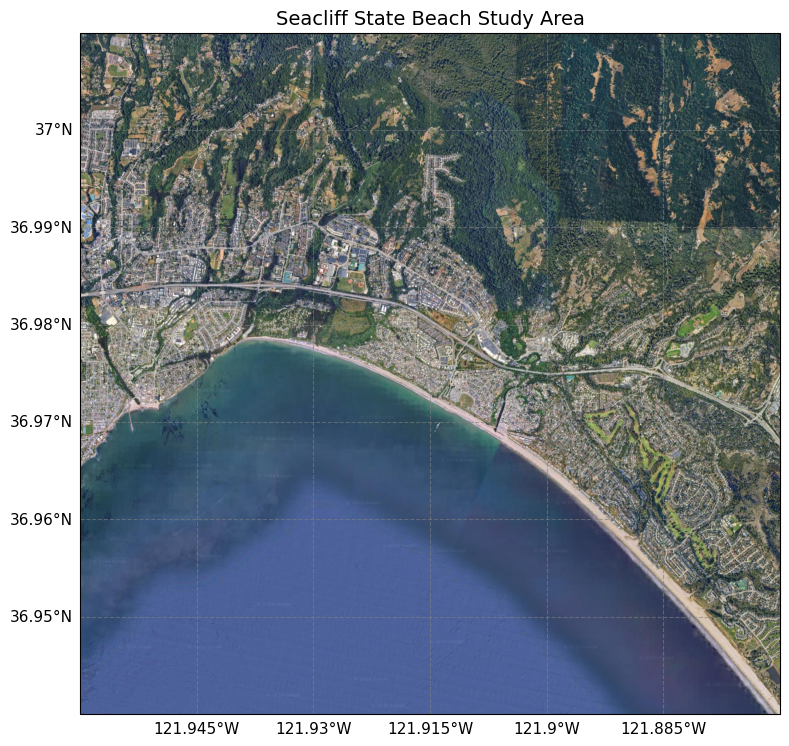

<Figure size 640x480 with 0 Axes>

In [42]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt

# -----------------------
# Define extent (your site)
# -----------------------
extent = [-121.96, -121.87, 36.94, 37.01]

# -----------------------
# Use GoogleTiles (works reliably)
# -----------------------
tiler = cimgt.GoogleTiles(style='satellite')   # <-- KEY FIX
mercator = tiler.crs

# -----------------------
# Create map
# -----------------------
fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection=mercator)

# Add satellite image
ax.add_image(tiler, 15)   # zoom level (try 14–17)

# Set extent properly
ax.set_extent(extent, crs=ccrs.PlateCarree())

# -----------------------
# Gridlines (your class style)
# -----------------------
gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.8,
    color="gray",
    alpha=0.6,
    linestyle="--"
)

gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 11}
gl.ylabel_style = {"size": 11}

# -----------------------
# Title
# -----------------------
plt.title("Seacliff State Beach Study Area", fontsize=14)

plt.tight_layout()
plt.show()
plt.savefig("Seacliff_base_map_grid.png", dpi=300, bbox_inches="tight")

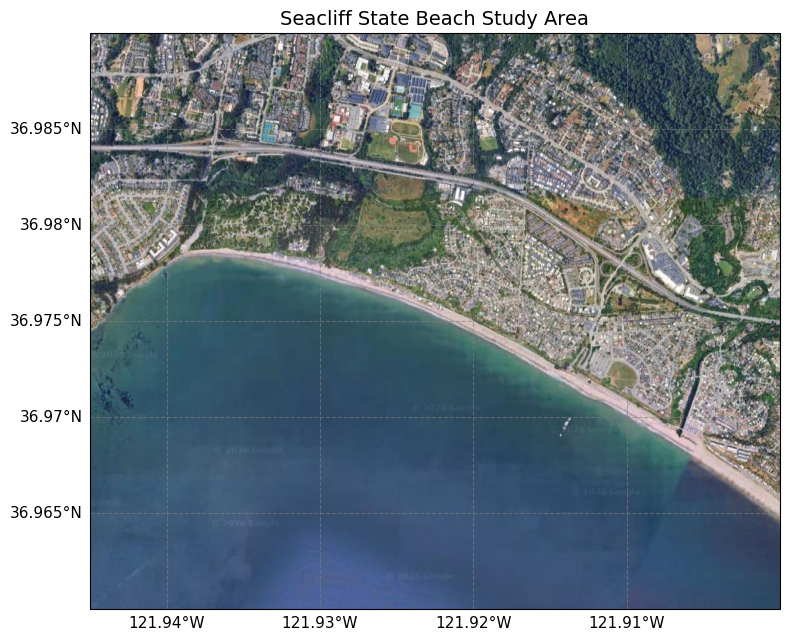

In [43]:
extent = [-121.945, -121.9, 36.96, 36.99]

# -----------------------
# Use GoogleTiles (works reliably)
# -----------------------
tiler = cimgt.GoogleTiles(style='satellite')   # <-- KEY FIX
mercator = tiler.crs

# -----------------------
# Create map
# -----------------------
fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection=mercator)

# Add satellite image
ax.add_image(tiler, 15)   # zoom level (try 14–17)

# Set extent properly
ax.set_extent(extent, crs=ccrs.PlateCarree())

# -----------------------
# Gridlines (your class style)
# -----------------------
gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.8,
    color="gray",
    alpha=0.6,
    linestyle="--"
)

gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 11}
gl.ylabel_style = {"size": 11}

# -----------------------
# Title
# -----------------------
plt.title("Seacliff State Beach Study Area", fontsize=14)

plt.tight_layout()
plt.show()

In [44]:
#New Code LinRegr

In [45]:
# New Code LinReg

# Make sure datetime columns are datetime
df2021['DateTimePT'] = pd.to_datetime(df2021['DateTimePT'], errors='coerce')
df2021['DateTimeUTC'] = pd.to_datetime(df2021['DateTimeUTC'], errors='coerce')

# Make sure TempData is numeric
df2021['TempData'] = pd.to_numeric(df2021['TempData'], errors='coerce')

# Check tag/transmitter matches
print(df2021[['Tag_shortName', 'Transmitter']].drop_duplicates().head(30))

# Recalculate residency index, keeping Transmitter
ri_list = []

tags = df2021['Tag_shortName'].dropna().unique()

for tag in tags:
    sub = df2021[df2021['Tag_shortName'] == tag].copy()
    sub = sub.sort_values('DateTimePT')

    if len(sub) > 0:
        days_detected = len(sub['day'].dropna().unique())
        first_day = sub['DateTimePT'].min()
        last_day = sub['DateTimePT'].max()
        ri = residency_index(days_detected, first_day, last_day)

        transmitter = sub['Transmitter'].iloc[0]

        ri_list.append([tag, transmitter, days_detected, first_day, last_day, ri])

ri_df = pd.DataFrame(
    ri_list,
    columns=['Tag_shortName', 'Transmitter', 'days_detected', 'first_day', 'last_day', 'RI']
)

print(ri_df.head())
print(ri_df.shape)

       Tag_shortName     Transmitter
759          2021-18   A69-9002-3593
791          2021-19   A69-9002-3595
813          2021-20   A69-9002-3589
1554         2021-22   A69-9002-3591
1563         2021-15    A69-9007-613
1622         2021-23   A69-9002-3585
1660         2021-26    A69-9007-611
1728         2021-27   A69-9002-3587
1798         2021-28    A69-9007-605
66235        2021-31    A69-9007-607
79611        2021-35   A69-9002-4561
91681        2021-37   A69-9002-4562
91753        2021-36   A69-9002-4560
113369       2021-43   A69-9002-6277
113381       2021-44  A69-9004-14387
113441       2021-45  A69-9004-14389
113447       2021-46  A69-9004-14395
113547       2021-47  A69-9004-14393
114303       2021-49    A69-9007-609
127125       2021-50  A69-9004-14391
  Tag_shortName    Transmitter  days_detected                     first_day  \
0       2021-18  A69-9002-3593             21 2021-06-01 19:46:17.835783936   
1       2021-19  A69-9002-3595             21 2021-06-01 20:27:24

In [46]:
np.unique(df2021['TempData'])

array([nan])

In [47]:
# Mean temperature per transmitter

df_temp = df2021[['Transmitter', 'TempData']].copy()
df_temp = df_temp.dropna()

temp_summary = df_temp.groupby('Transmitter')['TempData'].mean().reset_index()
temp_summary = temp_summary.rename(columns={'TempData':'MeanTemp'})

print(temp_summary.head())
print(temp_summary.shape)

Empty DataFrame
Columns: [Transmitter, MeanTemp]
Index: []
(0, 2)


In [48]:
# Combine residency and temperature data

reg_df = pd.merge(ri_df, temp_summary, on='Transmitter')
reg_df = reg_df.dropna()

print(reg_df.head())
print(reg_df.shape)

Empty DataFrame
Columns: [Tag_shortName, Transmitter, days_detected, first_day, last_day, RI, MeanTemp]
Index: []
(0, 7)


In [49]:
# Linear regression style from class

from scipy import stats

x = reg_df['MeanTemp']
y = reg_df['RI']

results = stats.linregress(x, y)
print(results)

ValueError: Inputs must not be empty.

In [ ]:
# Make regression line

m = results.slope
b = results.intercept

yhat = m*x + b

print('slope', m)
print('intercept', b)
print('r2', results.rvalue**2)
print('pvalue', results.pvalue)

In [ ]:
# Regression figure

plt.figure(figsize=(8,6))
plt.plot(reg_df['MeanTemp'], reg_df['RI'], 'o')
plt.plot(reg_df['MeanTemp'], yhat, '-')
plt.xlabel('Mean Temperature (°C)')
plt.ylabel('Residency Index')
plt.title('Relationship Between Mean Temperature and Residency Index')
plt.grid()
plt.show()

Figure 4: Shows the average mean depth of all JWS from months of June - November by the hour of day.

# Conclusion

 Based on this data, JWS tended to occupy shallower depths during the nighttime and early morning hours, followed by increased depth use during the mid-day and afteroon periods. These vertical movement patterns show that they prefer to occupy certain depths in the water column throughout the day. In addition, there seems to be seasonal variability in depth use. For example, in the later summer-fall months, JWS tend to have higher mean depths compared to earlier summer months, which may be indicating a shift in depth preference overtime. This can reflect either water temperature changes, prey availability, or stratification in the water column.
 
Overall, figures display JWS exhibiting both diel and seasonal variation in depth use, emphasizing the importance of fine-scale temporal structure in nearshore, coastal environments. Practicing with this historical dataset provides a foundation for how I can properly utilize it to compare to space usage of JWS for my thesis project. 

# Ideas for Future Work

Combing through this dataset gave me a prospective of how to properly clean these dense datasets, and also catching where there may be some equipment errors when given uncommon values. In the near future, I will be able to utilize this full dataset to then compare how JWS behave throughout a dynamic environment in Monterey Bay, potentially bridging how this region may emerge as a potential, fully-functioning nursery habitat like in Santa Barbara. Working with temperature logger data that expands throughout the water column in the array will be the next step to determine how much of a influence seasurface and seafloor temperature has on residency.

# References

Anderson James M., Emily Spurgeon., Brian S. Stirling, Jack May III, Patrick T. Rex, Bobby Hyla, Steve McCullough, Marten Thompson, Christopher G. Lowe. “High resolution acoustic telemetry reveals swim speeds and inferred field metabolic rates in juvenile white sharks (Carcharodon carcharias).” PLOS ONE 17 (2022) (6).  https://doi.org/10.1371/journal.pone.0268914.![image.png](attachment:image.png)

Dewar, Heidi., Michael Domeier. & Nicole Nasby-Lucas. “Insights into Young of the Year White Shark, Carcharodon carcharias, Behavior in the Southern California Bight.” Environmental Biology of Fishes 70 (2004) 133–143. https://doi.org/10.1023/B:EBFI.0000029343.54027.6a.![image-2.png](attachment:image-2.png)

Heupel M.R., John K. Carlson, Colin A. Simpfendorfer. “Shark nursery areas: concepts, definition, characterization and assumptions.” Mar Ecol Prog Ser 337 (2007):287-297. https://doi.org/10.3354/meps337287.![image-3.png](attachment:image-3.png)

Kraft et al. "Residency and space use estimation methods based on passive acoustic telemetry data." Movement Ecology (2023) 11:12 https://doi.org/10.1186/s40462-022-00364-z

Spurgeon, Emily, James M. Anderson, Yi Liu, Vianey Leos Barajas, Christopher G. Lowe. “Quantifying thermal cues that initiate mass emigrations in juvenile white sharks.” Sci Rep 12 (2022), 19874. https://doi.org/10.1038/s41598-022-24377-1.![image-4.png](attachment:image-4.png)